In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
# from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
# from keras.utils import np_utils   #np_utils
# from keras.callbacks import TensorBoard  #TensorBoard可视化

In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# 四级海况（波高2周期11.2水深50)
data_1 = pd.read_csv('t_2_11.2_50.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
data_1.describe()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000
mean,2000.050030,0.163048,5.607178,0.042822,-24.376800,-0.000003,-0.000050,0.000002,4994.70075,4957.142000
std,1154.714989,401.008617,93.005630,2.851035,379.528224,0.000376,0.018356,0.000222,753.57593,277.992156
min,0.100000,-1510.000000,-373.000000,-11.100000,-1390.000000,-0.001810,-0.067500,-0.001290,2290.00000,4120.000000
25%,1000.075015,-278.000000,-56.400000,-1.830000,-285.000000,-0.000251,-0.012900,-0.000136,4480.00000,4750.000000
50%,2000.050030,-5.955000,4.280000,0.030350,-31.600000,-0.000003,0.000474,-0.000001,4980.00000,4950.000000
75%,3000.025045,277.000000,64.700000,1.900000,236.000000,0.000246,0.012600,0.000135,5500.00000,5170.000000
max,4000.000060,1340.000000,452.000000,11.600000,1190.000000,0.001830,0.068400,0.001310,8110.00000,5700.000000


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [5]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [6]:
def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def RNSE(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))

def Acc(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [7]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入500步长输出10步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# 输入500步长输出30步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入500步长输出20步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
print(force150_x2.shape)
# # 输入100步长输出2步长
# force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
# force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
# print(force1100_x2.shape)


# 输入500步长输出40步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
print(force150_x4.shape)
# # 输入100步长输出4步长
# force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
# force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
# print(force1100_x4.shape)



# # 输入50步长输出6步长
# force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
# force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# # 输入100步长输出6步长
# force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)



# # 输入50步长输出8步长
# force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
# force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
# print(force150_x8.shape)
# # 输入100步长输出8步长
# force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
# force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
# print(force1100_x8.shape)

(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)


In [10]:
# print(force150_y1)
# print(force150_y2)
# print(force150_y3)
# print(force150_y4)

In [11]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入500步长输出10步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[3500:,:], 2, 509)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 500)
print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# 输入500步长输出30步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[3480:,:], 2, 529)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 500)
print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入500步长输出20步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[3490:,:], 2, 519)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 500)
print(heave50_x2.shape)
# # 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入500步长输出40步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[3470:,:], 2, 539)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 500)
print(heave50_x4.shape)
# # 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# # 输入50步长输出6步长
# heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
# heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
# print(heave50_x6.shape)
# # 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# # 输入50步长输出8步长
# heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
# heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
# print(heave50_x8.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# Surge
# 输入500步长输出10步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[3500:,:], 2, 509)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 500)
print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# 输入500步长输出30步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[3480:,:], 2, 529)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 500)
print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入500步长输出20步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[3490:,:], 2, 519)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 500)
print(surge50_x2.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入500步长输出40步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[3470:,:], 2, 539)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 500)
print(surge50_x4.shape)
# # 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# # 输入50步长输出6步长
# surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
# surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
# print(surge50_x6.shape)
# # 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# # 输入50步长输出8步长
# surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
# surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
# print(surge50_x8.shape)
# # 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# Pitch
# 输入500步长输出10步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[3500:,:], 2, 509)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 500)
print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# 输入500步长输出30步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[3480:,:], 2, 529)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 500)
print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入500步长输出20步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[3490:,:], 2, 519)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 500)
print(pitch50_x2.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入500步长输出40步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[3470:,:], 2, 539)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 500)
print(pitch50_x4.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# # 输入50步长输出6步长
# pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
# pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
# print(pitch50_x6.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# # 输入50步长输出8步长
# pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
# pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
# print(pitch50_x8.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)


### 模型比较

In [12]:
# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

#### 系泊缆力联合预测（时间窗500输出；步长10）

In [13]:
# 未来运动预测模型建立
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 4500, 7500, 12000)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_BiLSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 4200, 7500, 12000)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_BiLSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 4500, 7500, 12000)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_BiLSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 19s - loss: 0.0699 - val_loss: 0.0482 - 19s/epoch - 312ms/step
Epoch 2/30
60/60 - 12s - loss: 0.0336 - val_loss: 0.0241 - 12s/epoch - 207ms/step
Epoch 3/30
60/60 - 11s - loss: 0.0204 - val_loss: 0.0209 - 11s/epoch - 188ms/step
Epoch 4/30
60/60 - 11s - loss: 0.0183 - val_loss: 0.0135 - 11s/epoch - 186ms/step
Epoch 5/30
60/60 - 12s - loss: 0.0152 - val_loss: 0.0125 - 12s/epoch - 202ms/step
Epoch 6/30
60/60 - 14s - loss: 0.0146 - val_loss: 0.0114 - 14s/epoch - 237ms/step
Epoch 7/30
60/60 - 13s - loss: 0.0134 - val_loss: 0.0104 - 13s/epoch - 211ms/step
Epoch 8/30
60/60 - 11s - loss: 0.0121 - val_loss: 0.0093 - 11s/epoch - 189ms/step
Epoch 9/30
60/60 - 11s - loss: 0.0109 - val_loss: 0.0084 - 11s/epoch - 188ms/step
Epoch 10/30
60/60 - 11s - loss: 0.0100 - val_loss: 0.0080 - 11s/epoch - 186ms/step
Epoch 11/30
60/60 - 11s - loss: 0.0089 - val_loss: 0.0072 - 11s/epoch - 188ms/step
Epoch 12/30
60/60 - 12s - loss: 0.0082 - val_loss: 0.0067 - 12s/epoch - 192ms/step
Epoch 13/30
6

Epoch 15/30
60/60 - 11s - loss: 0.0294 - val_loss: 0.0280 - 11s/epoch - 186ms/step
Epoch 16/30
60/60 - 11s - loss: 0.0290 - val_loss: 0.0273 - 11s/epoch - 186ms/step
Epoch 17/30
60/60 - 11s - loss: 0.0291 - val_loss: 0.0277 - 11s/epoch - 186ms/step
Epoch 18/30
60/60 - 12s - loss: 0.0289 - val_loss: 0.0269 - 12s/epoch - 203ms/step
Epoch 19/30
60/60 - 11s - loss: 0.0278 - val_loss: 0.0254 - 11s/epoch - 186ms/step
Epoch 20/30
60/60 - 11s - loss: 0.0288 - val_loss: 0.0259 - 11s/epoch - 186ms/step
Epoch 21/30
60/60 - 11s - loss: 0.0315 - val_loss: 0.0263 - 11s/epoch - 187ms/step
Epoch 22/30
60/60 - 11s - loss: 0.0280 - val_loss: 0.0269 - 11s/epoch - 186ms/step
Epoch 23/30
60/60 - 12s - loss: 0.0285 - val_loss: 0.0253 - 12s/epoch - 196ms/step
Epoch 24/30
60/60 - 12s - loss: 0.0283 - val_loss: 0.0263 - 12s/epoch - 194ms/step
Epoch 25/30
60/60 - 11s - loss: 0.0320 - val_loss: 0.0277 - 11s/epoch - 186ms/step
Epoch 26/30
60/60 - 11s - loss: 0.0288 - val_loss: 0.0258 - 11s/epoch - 187ms/step
Epoc

In [14]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
# print(pretrain_heave50_Y1.shape)
# print(pretrain_surge50_Y1.shape)
# print(pretrain_pitch50_Y1.shape)

94/94 [==============================] - 4s 37ms/step


In [15]:
# 输入500步长输出10步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 4500, 7500, 12000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [17]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.0199 - val_loss: 0.0158 - 2s/epoch - 137ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0138 - 86ms/epoch - 7ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0134 - val_loss: 0.0138 - 74ms/epoch - 6ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0145 - val_loss: 0.0133 - 92ms/epoch - 8ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0135 - 89ms/epoch - 7ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0130 - 84ms/epoch - 7ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0128 - val_loss: 0.0130 - 101ms/epoch - 8ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0131 - 78ms/epoch - 6ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0131 - 76ms/epoch - 6ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0131 - 81ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0131 - 77ms/epoch - 6ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0131 - 81ms/epoch - 7ms/step
Epoch 13/100

Epoch 100/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 73ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 75ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0131 - 69ms/epoch - 6

Epoch 198/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 65ms/epoch - 5ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 75ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 82ms/epoch - 7ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 88ms/epoch - 7ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 69ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 75ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 80ms/epoch - 7ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 75ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0131 - 74ms/epoch - 6

Epoch 394/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 65ms/epoch - 5ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 398/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 399/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 400/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 401/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 402/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 75ms/epoch - 6ms/step
Epoch 403/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 404/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 405/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 75ms/epoch - 6ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 77ms/epoch - 6ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 65ms/epoch - 5ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 65ms/epoch - 5ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 73ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 77ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 65ms/epoch - 5ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 65ms/epoch - 5

Epoch 884/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 76ms/epoch - 6ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 86ms/epoch - 7ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 71ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6

Epoch 982/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 66ms/epoch - 5ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 65ms/epoch - 5ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 69ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 67ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 78ms/epoch - 6ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 76ms/epoch - 6ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 70ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0131 - 68ms/epoch - 6

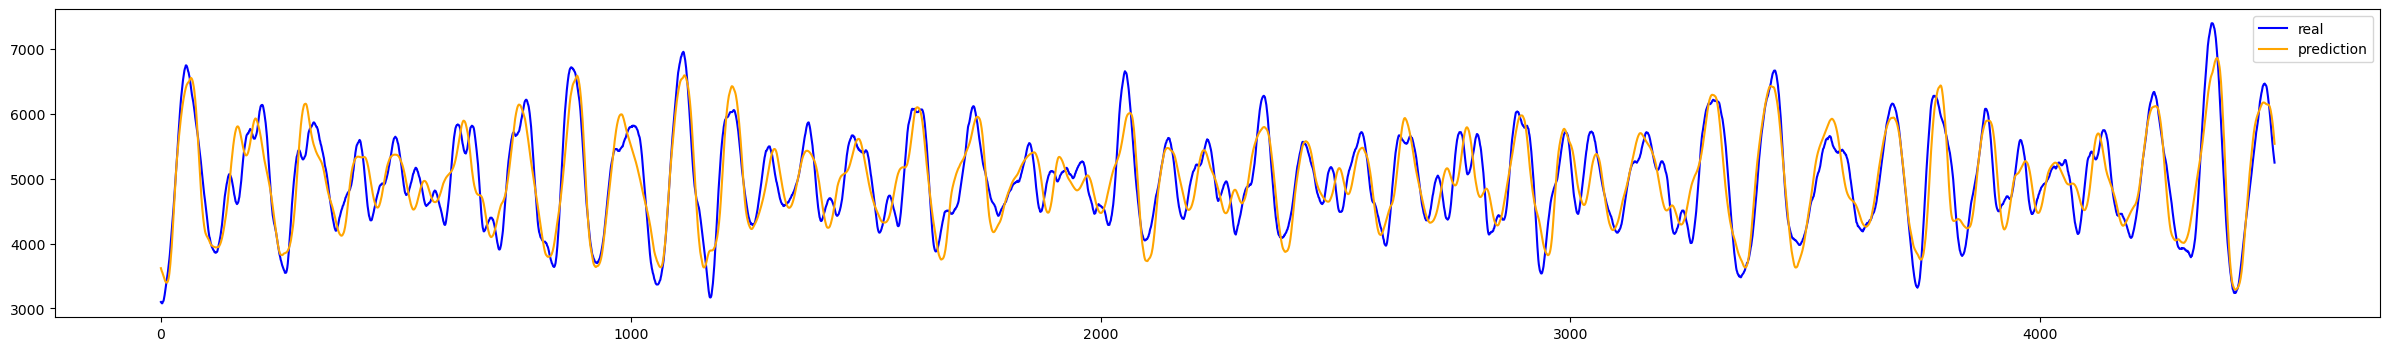

In [18]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force1500_步长10_BiLSTM.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [19]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3500:,:], 4, 509)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 4500, 7500, 12000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [21]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/1000
12/12 - 1s - loss: 0.0749 - val_loss: 0.0517 - 1s/epoch - 111ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0358 - val_loss: 0.0330 - 107ms/epoch - 9ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0324 - val_loss: 0.0340 - 96ms/epoch - 8ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0297 - val_loss: 0.0332 - 97ms/epoch - 8ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0305 - val_loss: 0.0310 - 104ms/epoch - 9ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0277 - val_loss: 0.0297 - 111ms/epoch - 9ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0277 - val_loss: 0.0300 - 96ms/epoch - 8ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0282 - val_loss: 0.0303 - 75ms/epoch - 6ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0281 - val_loss: 0.0300 - 83ms/epoch - 7ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0280 - val_loss: 0.0300 - 80ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0280 - val_loss: 0.0300 - 88ms/epoch - 7ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0281 - val_loss: 0.0300 - 85ms/epoch - 7ms/step
Epoch 13/1

Epoch 100/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 73ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 90ms/epoch - 7ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 81ms/epoch - 7ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 69ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 78ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 70ms/epoch - 6ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 71ms/epoch - 6ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 70ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 88ms/epoch - 7ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 123ms/epoch - 10ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 89ms/epoch - 7ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0271 - val_loss: 0.0297 - 70ms/epoch -

Epoch 198/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 65ms/epoch - 5ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 71ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 77ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 79ms/epoch - 7ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 75ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 72ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 71ms/epoch - 6ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 74ms/epoch - 6ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 69ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 70ms/epoch - 6ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 70ms/epoch - 6ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0268 - val_loss: 0.0297 - 69ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 72ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 74ms/epoch - 6ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 75ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 70ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 70ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 71ms/epoch - 6ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0296 - 71ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0261 - val_loss: 0.0296 - 69ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0261 - val_loss: 0.0296 - 80ms/epoch - 7ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0261 - val_loss: 0.0296 - 67ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0261 - val_loss: 0.0296 - 71ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0261 - val_loss: 0.0296 - 76ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0239 - val_loss: 0.0285 - 69ms/epoch - 6ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0239 - val_loss: 0.0285 - 71ms/epoch - 6ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0239 - val_loss: 0.0285 - 71ms/epoch - 6ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 69ms/epoch - 6ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 71ms/epoch - 6ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 77ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 70ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 72ms/epoch - 6ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 70ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 67ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 70ms/epoch - 6ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0238 - val_loss: 0.0285 - 73ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0232 - val_loss: 0.0287 - 70ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0232 - val_loss: 0.0287 - 78ms/epoch - 6ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0232 - val_loss: 0.0287 - 70ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0232 - val_loss: 0.0287 - 70ms/epoch - 6ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0232 - val_loss: 0.0287 - 71ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0232 - val_loss: 0.0287 - 72ms/epoch - 6ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0231 - val_loss: 0.0287 - 71ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0231 - val_loss: 0.0287 - 70ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0231 - val_loss: 0.0286 - 72ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0231 - val_loss: 0.0286 - 77ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0231 - val_loss: 0.0286 - 70ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0231 - val_loss: 0.0286 - 71ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0219 - val_loss: 0.0296 - 71ms/epoch - 6ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0219 - val_loss: 0.0296 - 68ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0219 - val_loss: 0.0296 - 69ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0219 - val_loss: 0.0296 - 70ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0219 - val_loss: 0.0297 - 70ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0297 - 72ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0297 - 69ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0298 - 70ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0298 - 77ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0298 - 70ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0299 - 71ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0299 - 71ms/epoch - 6

Epoch 884/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0316 - 71ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0316 - 67ms/epoch - 6ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0316 - 74ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0316 - 72ms/epoch - 6ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 70ms/epoch - 6ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 70ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 67ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 71ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 70ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 73ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 73ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0317 - 73ms/epoch - 6

Epoch 982/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 69ms/epoch - 6ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 73ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 71ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 71ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0203 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0202 - val_loss: 0.0321 - 70ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0202 - val_loss: 0.0321 - 70ms/epoch - 6

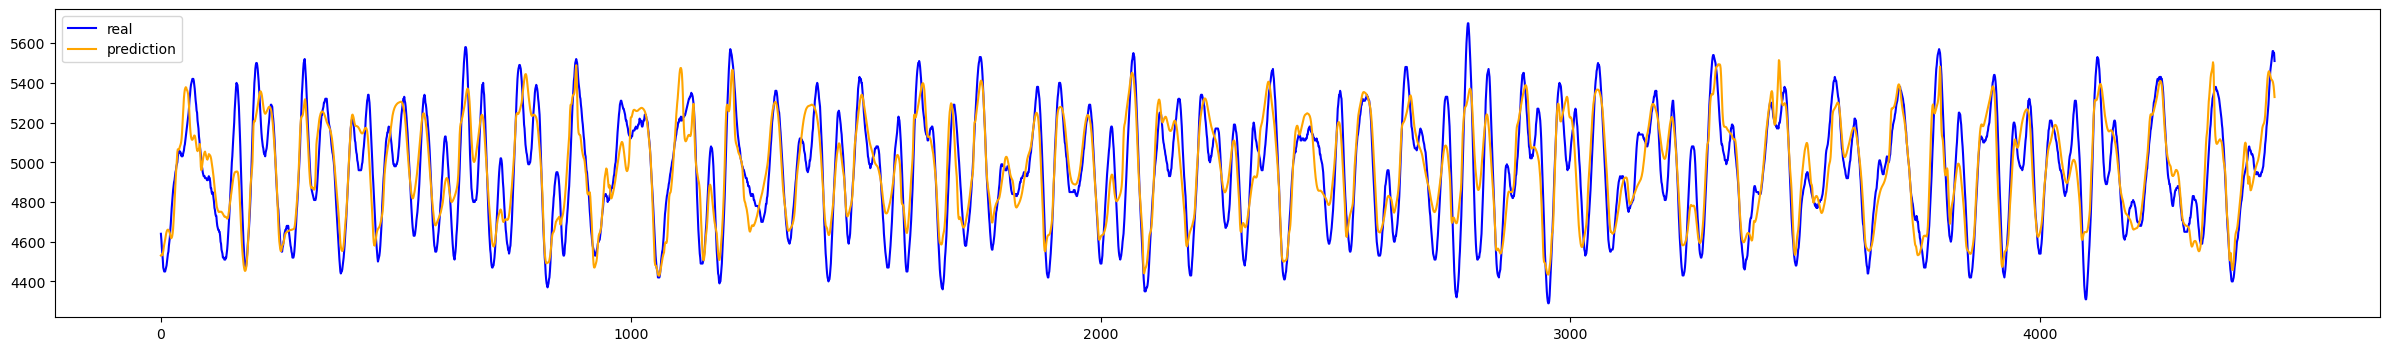

In [22]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force2500_步长10_BiLSTM.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

In [23]:
RNSE(valid50_y_Force1,N_pre50_Y_Force1)
Acc(valid50_y_Force1,N_pre50_Y_Force1)

RMSE(sklearn): 0.11423558381098504
Acc: 0.9261462721683731


In [24]:
RNSE(valid50_y_Force2,N_pre50_Y_Force2)
Acc(valid50_y_Force2,N_pre50_Y_Force2)

RMSE(sklearn): 0.17933181846162558
Acc: 0.9047951070685742


#### 系泊缆力联合预测（时间窗500输出；步长20）

In [13]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 12000)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_BiLSTM(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 12000)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_BiLSTM(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 12000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_BiLSTM(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 25s - loss: 0.0887 - val_loss: 0.0469 - 25s/epoch - 417ms/step
Epoch 2/30
60/60 - 12s - loss: 0.0366 - val_loss: 0.0310 - 12s/epoch - 195ms/step
Epoch 3/30
60/60 - 11s - loss: 0.0375 - val_loss: 0.0233 - 11s/epoch - 187ms/step
Epoch 4/30
60/60 - 11s - loss: 0.0300 - val_loss: 0.0222 - 11s/epoch - 189ms/step
Epoch 5/30
60/60 - 11s - loss: 0.0276 - val_loss: 0.0240 - 11s/epoch - 186ms/step
Epoch 6/30
60/60 - 12s - loss: 0.0244 - val_loss: 0.0213 - 12s/epoch - 205ms/step
Epoch 7/30
60/60 - 11s - loss: 0.0237 - val_loss: 0.0208 - 11s/epoch - 187ms/step
Epoch 8/30
60/60 - 11s - loss: 0.0243 - val_loss: 0.0217 - 11s/epoch - 187ms/step
Epoch 9/30
60/60 - 11s - loss: 0.0253 - val_loss: 0.0223 - 11s/epoch - 187ms/step
Epoch 10/30
60/60 - 11s - loss: 0.0244 - val_loss: 0.0215 - 11s/epoch - 187ms/step
Epoch 11/30
60/60 - 12s - loss: 0.0236 - val_loss: 0.0215 - 12s/epoch - 197ms/step
Epoch 12/30
60/60 - 12s - loss: 0.0219 - val_loss: 0.0185 - 12s/epoch - 194ms/step
Epoch 13/30
6

Epoch 15/30
60/60 - 11s - loss: 0.0277 - val_loss: 0.0258 - 11s/epoch - 183ms/step
Epoch 16/30
60/60 - 11s - loss: 0.0274 - val_loss: 0.0244 - 11s/epoch - 184ms/step
Epoch 17/30
60/60 - 12s - loss: 0.0267 - val_loss: 0.0253 - 12s/epoch - 202ms/step
Epoch 18/30
60/60 - 12s - loss: 0.0267 - val_loss: 0.0236 - 12s/epoch - 196ms/step
Epoch 19/30
60/60 - 11s - loss: 0.0266 - val_loss: 0.0259 - 11s/epoch - 184ms/step
Epoch 20/30
60/60 - 11s - loss: 0.0278 - val_loss: 0.0257 - 11s/epoch - 185ms/step
Epoch 21/30
60/60 - 11s - loss: 0.0271 - val_loss: 0.0249 - 11s/epoch - 183ms/step
Epoch 22/30
60/60 - 11s - loss: 0.0263 - val_loss: 0.0239 - 11s/epoch - 183ms/step
Epoch 23/30
60/60 - 12s - loss: 0.0254 - val_loss: 0.0227 - 12s/epoch - 202ms/step
Epoch 24/30
60/60 - 11s - loss: 0.0248 - val_loss: 0.0222 - 11s/epoch - 184ms/step
Epoch 25/30
60/60 - 11s - loss: 0.0246 - val_loss: 0.0218 - 11s/epoch - 183ms/step
Epoch 26/30
60/60 - 11s - loss: 0.0241 - val_loss: 0.0213 - 11s/epoch - 184ms/step
Epoc

In [14]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

94/94 [==============================] - 3s 36ms/step
(3000, 1)
(3000, 1)
(3000, 1)


In [15]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 4500, 7500, 12000)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [17]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.0243 - val_loss: 0.0199 - 2s/epoch - 154ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0186 - val_loss: 0.0150 - 93ms/epoch - 8ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0180 - val_loss: 0.0161 - 85ms/epoch - 7ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0142 - 85ms/epoch - 7ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0144 - 77ms/epoch - 6ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0142 - 89ms/epoch - 7ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0142 - 83ms/epoch - 7ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0142 - 79ms/epoch - 7ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0142 - 72ms/epoch - 6ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0142 - 82ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0142 - 78ms/epoch - 6ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0142 - 83ms/epoch - 7ms/step
Epoch 13/1000

Epoch 100/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 75ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 74ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 74ms/epoch - 6ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 68ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 67ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 68ms/epoch - 6ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 70ms/epoch - 6ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 75ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 70ms/epoch - 6ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 69ms/epoch - 6ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 69ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 69ms/epoch - 6

Epoch 198/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0141 - 86ms/epoch - 7ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0141 - 88ms/epoch - 7ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0141 - 70ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0141 - 89ms/epoch - 7ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0141 - 87ms/epoch - 7ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0141 - 70ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0142 - 85ms/epoch - 7ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0142 - 96ms/epoch - 8ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0141 - 70ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0141 - 79ms/epoch - 7ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0141 - 91ms/epoch - 8ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0141 - 88ms/epoch - 7

Epoch 296/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0141 - 70ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0141 - 68ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 67ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0141 - 69ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 73ms/epoch - 6ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 72ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 68ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 67ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0140 - 65ms/epoch - 5

Epoch 394/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 70ms/epoch - 6ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 68ms/epoch - 6ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 68ms/epoch - 6ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 66ms/epoch - 5ms/step
Epoch 398/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 69ms/epoch - 6ms/step
Epoch 399/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 70ms/epoch - 6ms/step
Epoch 400/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 69ms/epoch - 6ms/step
Epoch 401/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 68ms/epoch - 6ms/step
Epoch 402/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0135 - 66ms/epoch - 5ms/step
Epoch 403/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0135 - 69ms/epoch - 6ms/step
Epoch 404/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0135 - 74ms/epoch - 6ms/step
Epoch 405/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0135 - 67ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 71ms/epoch - 6ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 77ms/epoch - 6ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 68ms/epoch - 6ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 69ms/epoch - 6ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 68ms/epoch - 6ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 68ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 67ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 66ms/epoch - 5ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 70ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 68ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 69ms/epoch - 6ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0138 - 69ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 70ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 70ms/epoch - 6ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 71ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 90ms/epoch - 7ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 72ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 79ms/epoch - 7ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 74ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 73ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 75ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 71ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 66ms/epoch - 5ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0139 - 70ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 69ms/epoch - 6ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 69ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 68ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 68ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 68ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 67ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 78ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 90ms/epoch - 7ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 80ms/epoch - 7ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 75ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 70ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0139 - 70ms/epoch - 6

Epoch 884/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 66ms/epoch - 5ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 70ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 84ms/epoch - 7ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 76ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 70ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 66ms/epoch - 5ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 69ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0140 - 90ms/epoch - 7

Epoch 982/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 70ms/epoch - 6ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 69ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 66ms/epoch - 5ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 78ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 75ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 70ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 69ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 67ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 68ms/epoch - 6ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 65ms/epoch - 5ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 69ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0142 - 69ms/epoch - 6

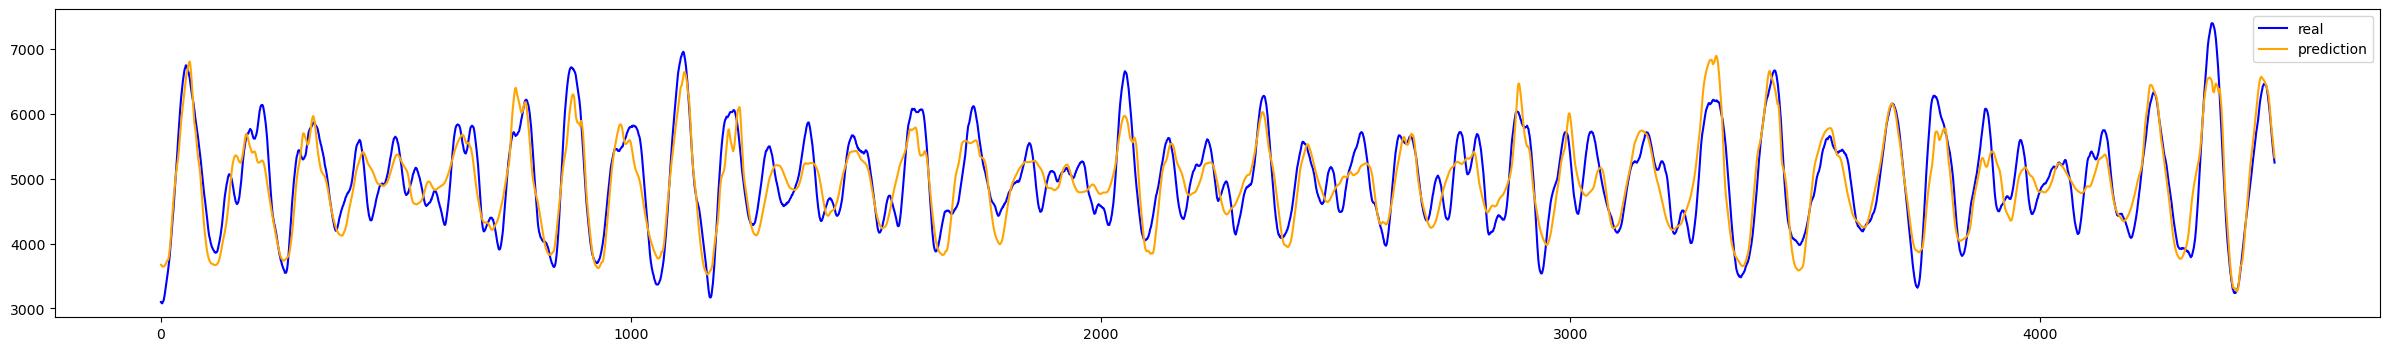

In [18]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force1500_步长20_BiLSTM.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [19]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3490:,:], 4, 519)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 4500, 7500, 12000)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [21]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/1000
12/12 - 1s - loss: 0.0861 - val_loss: 0.0823 - 1s/epoch - 120ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0683 - val_loss: 0.0743 - 83ms/epoch - 7ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0667 - val_loss: 0.0741 - 82ms/epoch - 7ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0636 - val_loss: 0.0727 - 80ms/epoch - 7ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0641 - val_loss: 0.0729 - 81ms/epoch - 7ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0630 - val_loss: 0.0718 - 85ms/epoch - 7ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0629 - val_loss: 0.0716 - 107ms/epoch - 9ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0626 - val_loss: 0.0714 - 88ms/epoch - 7ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0621 - val_loss: 0.0714 - 77ms/epoch - 6ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0620 - val_loss: 0.0714 - 84ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0618 - val_loss: 0.0714 - 79ms/epoch - 7ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0617 - val_loss: 0.0714 - 77ms/epoch - 6ms/step
Epoch 13/100

Epoch 100/1000
12/12 - 0s - loss: 0.0602 - val_loss: 0.0711 - 72ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0601 - val_loss: 0.0711 - 69ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0601 - val_loss: 0.0711 - 69ms/epoch - 6ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0601 - val_loss: 0.0711 - 74ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0601 - val_loss: 0.0711 - 70ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0601 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0601 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0600 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0600 - val_loss: 0.0710 - 71ms/epoch - 6ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0600 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0599 - val_loss: 0.0709 - 72ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0599 - val_loss: 0.0709 - 69ms/epoch - 6

Epoch 198/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 71ms/epoch - 6ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 69ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 67ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 69ms/epoch - 6ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 67ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 70ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 69ms/epoch - 6ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 70ms/epoch - 6ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 70ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 69ms/epoch - 6ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0581 - val_loss: 0.0708 - 70ms/epoch - 6ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0580 - val_loss: 0.0708 - 68ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0577 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 66ms/epoch - 5ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 71ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 75ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 71ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 75ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 72ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 70ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 72ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0576 - val_loss: 0.0710 - 77ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0565 - val_loss: 0.0719 - 85ms/epoch - 7ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0565 - val_loss: 0.0719 - 93ms/epoch - 8ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0565 - val_loss: 0.0719 - 81ms/epoch - 7ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0565 - val_loss: 0.0719 - 85ms/epoch - 7ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0565 - val_loss: 0.0719 - 80ms/epoch - 7ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0565 - val_loss: 0.0719 - 73ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0564 - val_loss: 0.0719 - 84ms/epoch - 7ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0564 - val_loss: 0.0719 - 92ms/epoch - 8ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0564 - val_loss: 0.0720 - 77ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0564 - val_loss: 0.0720 - 71ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0564 - val_loss: 0.0720 - 83ms/epoch - 7ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0564 - val_loss: 0.0720 - 83ms/epoch - 7

Epoch 688/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 71ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 66ms/epoch - 5ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 69ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 66ms/epoch - 5ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 70ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 69ms/epoch - 6ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 71ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 71ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 79ms/epoch - 7ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 73ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 72ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0558 - val_loss: 0.0721 - 71ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 71ms/epoch - 6ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 71ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 71ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 71ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 71ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 71ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0555 - val_loss: 0.0722 - 77ms/epoch - 6

Epoch 884/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 71ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 71ms/epoch - 6ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 70ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 72ms/epoch - 6ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 72ms/epoch - 6ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 73ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 74ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 71ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 72ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 69ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 69ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0553 - val_loss: 0.0723 - 72ms/epoch - 6

Epoch 982/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0723 - 70ms/epoch - 6ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0723 - 71ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0723 - 70ms/epoch - 6ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0723 - 71ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0723 - 70ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 69ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 67ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 70ms/epoch - 6ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 69ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0552 - val_loss: 0.0722 - 72ms/epoch - 6

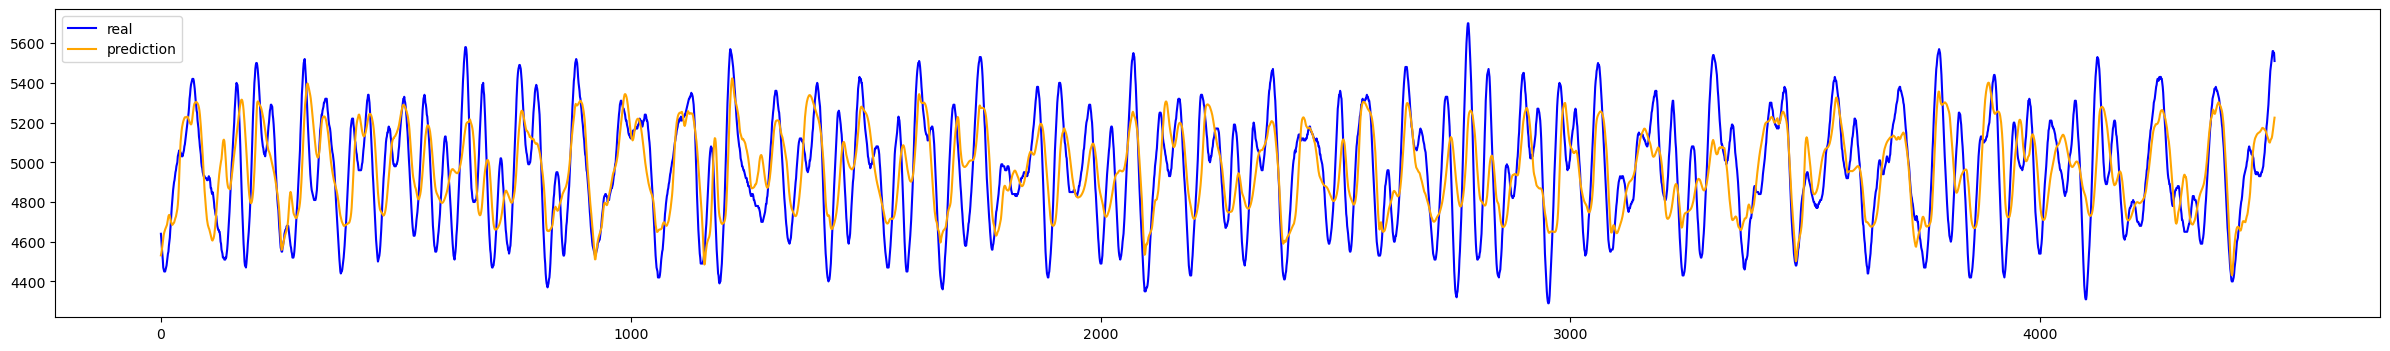

In [22]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force2500_步长20_BiLSTM.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

In [23]:
RNSE(valid50_y2_Force1,N_pre50_Y2_Force1)
RNSE(valid50_y2_Force2,N_pre50_Y2_Force2)

print('————————')

Acc(valid50_y2_Force1,N_pre50_Y2_Force1)
Acc(valid50_y2_Force2,N_pre50_Y2_Force2)

RMSE(sklearn): 0.1191203401594459
RMSE(sklearn): 0.2687673844233826
————————
Acc: 0.8785547944036363
Acc: 0.7321302614413947


#### 系泊缆力联合预测（时间窗500输出；步长30）

In [13]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 12000)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_BiLSTM(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 12000)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_BiLSTM(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 12000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_BiLSTM(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 19s - loss: 0.0843 - val_loss: 0.0470 - 19s/epoch - 318ms/step
Epoch 2/30
60/60 - 11s - loss: 0.0374 - val_loss: 0.0369 - 11s/epoch - 186ms/step
Epoch 3/30
60/60 - 11s - loss: 0.0316 - val_loss: 0.0268 - 11s/epoch - 186ms/step
Epoch 4/30
60/60 - 12s - loss: 0.0301 - val_loss: 0.0275 - 12s/epoch - 193ms/step
Epoch 5/30
60/60 - 11s - loss: 0.0288 - val_loss: 0.0292 - 11s/epoch - 189ms/step
Epoch 6/30
60/60 - 12s - loss: 0.0283 - val_loss: 0.0295 - 12s/epoch - 192ms/step
Epoch 7/30
60/60 - 12s - loss: 0.0286 - val_loss: 0.0263 - 12s/epoch - 200ms/step
Epoch 8/30
60/60 - 11s - loss: 0.0298 - val_loss: 0.0240 - 11s/epoch - 187ms/step
Epoch 9/30
60/60 - 11s - loss: 0.0297 - val_loss: 0.0239 - 11s/epoch - 190ms/step
Epoch 10/30
60/60 - 11s - loss: 0.0287 - val_loss: 0.0303 - 11s/epoch - 189ms/step
Epoch 11/30
60/60 - 11s - loss: 0.0255 - val_loss: 0.0299 - 11s/epoch - 187ms/step
Epoch 12/30
60/60 - 11s - loss: 0.0245 - val_loss: 0.0213 - 11s/epoch - 188ms/step
Epoch 13/30
6

Epoch 15/30
60/60 - 11s - loss: 0.0361 - val_loss: 0.0365 - 11s/epoch - 185ms/step
Epoch 16/30
60/60 - 12s - loss: 0.0358 - val_loss: 0.0360 - 12s/epoch - 192ms/step
Epoch 17/30
60/60 - 11s - loss: 0.0370 - val_loss: 0.0353 - 11s/epoch - 185ms/step
Epoch 18/30
60/60 - 11s - loss: 0.0349 - val_loss: 0.0343 - 11s/epoch - 186ms/step
Epoch 19/30
60/60 - 12s - loss: 0.0340 - val_loss: 0.0356 - 12s/epoch - 198ms/step
Epoch 20/30
60/60 - 11s - loss: 0.0350 - val_loss: 0.0342 - 11s/epoch - 186ms/step
Epoch 21/30
60/60 - 11s - loss: 0.0341 - val_loss: 0.0344 - 11s/epoch - 188ms/step
Epoch 22/30
60/60 - 11s - loss: 0.0337 - val_loss: 0.0335 - 11s/epoch - 189ms/step
Epoch 23/30
60/60 - 11s - loss: 0.0331 - val_loss: 0.0333 - 11s/epoch - 185ms/step
Epoch 24/30
60/60 - 11s - loss: 0.0333 - val_loss: 0.0343 - 11s/epoch - 189ms/step
Epoch 25/30
60/60 - 12s - loss: 0.0335 - val_loss: 0.0329 - 12s/epoch - 196ms/step
Epoch 26/30
60/60 - 11s - loss: 0.0325 - val_loss: 0.0330 - 11s/epoch - 186ms/step
Epoc

In [14]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

94/94 [==============================] - 3s 36ms/step
(3000, 1)
(3000, 1)
(3000, 1)


In [15]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 4500, 7500, 12000)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [17]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.0231 - val_loss: 0.0186 - 2s/epoch - 152ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0178 - val_loss: 0.0166 - 96ms/epoch - 8ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0182 - val_loss: 0.0154 - 81ms/epoch - 7ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0146 - 89ms/epoch - 7ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0149 - 84ms/epoch - 7ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0147 - 87ms/epoch - 7ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0146 - 92ms/epoch - 8ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0147 - 92ms/epoch - 8ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0147 - 94ms/epoch - 8ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0147 - 86ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0147 - 81ms/epoch - 7ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0147 - 69ms/epoch - 6ms/step
Epoch 13/1000

Epoch 100/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 71ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 69ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 70ms/epoch - 6ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 69ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 68ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 66ms/epoch - 5ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 74ms/epoch - 6ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 77ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 69ms/epoch - 6ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 74ms/epoch - 6ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 68ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0146 - 67ms/epoch - 6

Epoch 198/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 69ms/epoch - 6ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 75ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 67ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 66ms/epoch - 5ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 76ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 71ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 68ms/epoch - 6ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 73ms/epoch - 6ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 68ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 67ms/epoch - 6ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 72ms/epoch - 6ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0146 - 70ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0149 - 75ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0151 - 77ms/epoch - 6ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0153 - val_loss: 0.0151 - 74ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0150 - 69ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0151 - 67ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0151 - 65ms/epoch - 5ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0150 - 69ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0153 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0146 - 69ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0145 - 68ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0145 - 69ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0145 - 89ms/epoch - 7

Epoch 394/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0145 - 80ms/epoch - 7ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0145 - 69ms/epoch - 6ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0145 - 81ms/epoch - 7ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0145 - 88ms/epoch - 7ms/step
Epoch 398/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0146 - 69ms/epoch - 6ms/step
Epoch 399/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0149 - 77ms/epoch - 6ms/step
Epoch 400/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0149 - 85ms/epoch - 7ms/step
Epoch 401/1000
12/12 - 0s - loss: 0.0153 - val_loss: 0.0145 - 72ms/epoch - 6ms/step
Epoch 402/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0144 - 79ms/epoch - 7ms/step
Epoch 403/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0144 - 83ms/epoch - 7ms/step
Epoch 404/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0145 - 80ms/epoch - 7ms/step
Epoch 405/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0147 - 77ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 75ms/epoch - 6ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 66ms/epoch - 5ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 76ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 79ms/epoch - 7ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 66ms/epoch - 5ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 72ms/epoch - 6ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 74ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 75ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 66ms/epoch - 5ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 66ms/epoch - 5

Epoch 884/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 73ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6

Epoch 982/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 75ms/epoch - 6ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 70ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 67ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 74ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 66ms/epoch - 5ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 69ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0144 - 68ms/epoch - 6

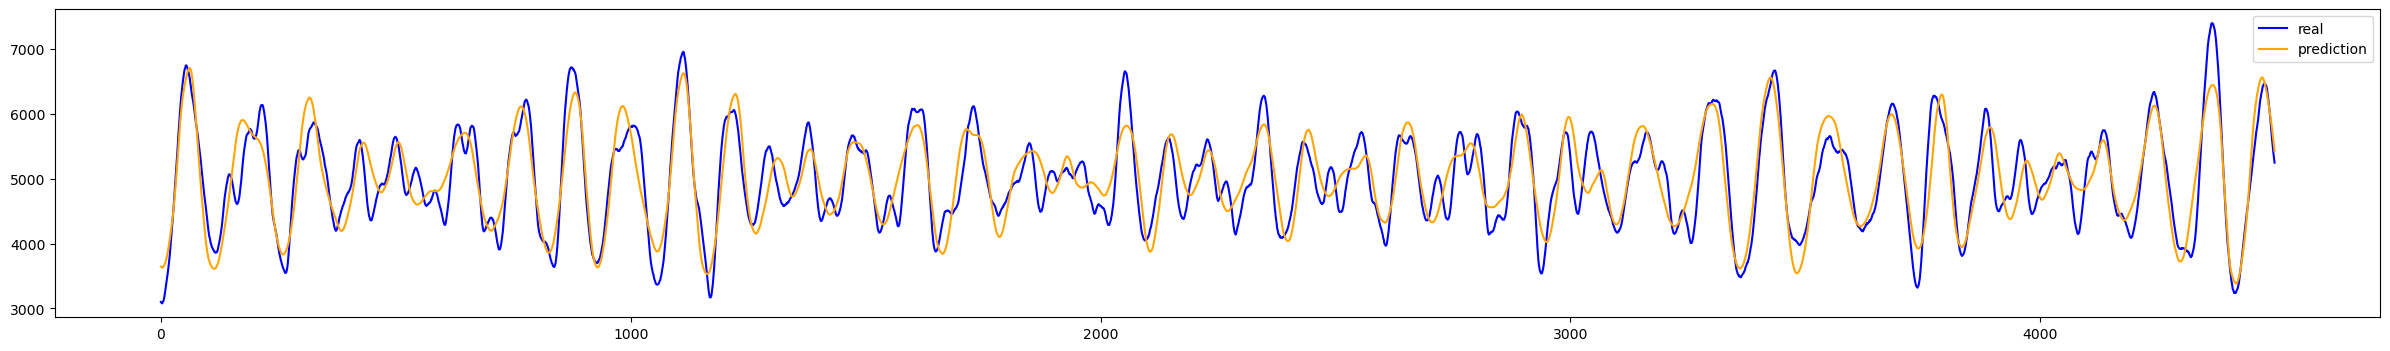

In [18]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force1500_步长30_BiLSTM.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [19]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3480:,:], 4, 529)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 4500, 7500, 12000)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [21]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/1000
12/12 - 1s - loss: 0.1003 - val_loss: 0.1024 - 1s/epoch - 110ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0828 - val_loss: 0.0893 - 97ms/epoch - 8ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0779 - val_loss: 0.0894 - 98ms/epoch - 8ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0768 - val_loss: 0.0880 - 107ms/epoch - 9ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0752 - val_loss: 0.0890 - 80ms/epoch - 7ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0750 - val_loss: 0.0894 - 92ms/epoch - 8ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0752 - val_loss: 0.0902 - 94ms/epoch - 8ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0755 - val_loss: 0.0898 - 82ms/epoch - 7ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0752 - val_loss: 0.0891 - 99ms/epoch - 8ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0891 - 108ms/epoch - 9ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0744 - val_loss: 0.0892 - 84ms/epoch - 7ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0893 - 102ms/epoch - 8ms/step
Epoch 13/1

Epoch 100/1000
12/12 - 0s - loss: 0.0726 - val_loss: 0.0890 - 74ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0725 - val_loss: 0.0890 - 72ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0726 - val_loss: 0.0890 - 67ms/epoch - 6ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0727 - val_loss: 0.0890 - 72ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0728 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0727 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0726 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0725 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0725 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0725 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0725 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0725 - val_loss: 0.0893 - 71ms/epoch - 6

Epoch 198/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 77ms/epoch - 6ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 73ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 72ms/epoch - 6ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 77ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 72ms/epoch - 6ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0722 - val_loss: 0.0892 - 71ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 67ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 77ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 72ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 72ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 73ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 72ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 71ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 70ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0892 - 68ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 89ms/epoch - 7ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 79ms/epoch - 7ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 80ms/epoch - 7ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 87ms/epoch - 7ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 82ms/epoch - 7ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 82ms/epoch - 7ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 77ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 65ms/epoch - 5ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0891 - 67ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 95ms/epoch - 8ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 71ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 101ms/epoch - 8ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 67ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 70ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 73ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 71ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 72ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0891 - 78ms/epoch - 

Epoch 884/1000
12/12 - 0s - loss: 0.0717 - val_loss: 0.0893 - 78ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0717 - val_loss: 0.0893 - 84ms/epoch - 7ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0893 - 78ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0893 - 77ms/epoch - 6ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0893 - 89ms/epoch - 7ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0893 - 85ms/epoch - 7ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0893 - 82ms/epoch - 7ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0894 - 79ms/epoch - 7ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0894 - 78ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0715 - val_loss: 0.0894 - 74ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0715 - val_loss: 0.0894 - 69ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0715 - val_loss: 0.0894 - 72ms/epoch - 6

Epoch 982/1000
12/12 - 0s - loss: 0.0683 - val_loss: 0.0922 - 72ms/epoch - 6ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0682 - val_loss: 0.0922 - 73ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0682 - val_loss: 0.0921 - 70ms/epoch - 6ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0681 - val_loss: 0.0921 - 69ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0680 - val_loss: 0.0921 - 67ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0680 - val_loss: 0.0920 - 70ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0679 - val_loss: 0.0920 - 71ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0679 - val_loss: 0.0919 - 70ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0678 - val_loss: 0.0919 - 79ms/epoch - 7ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0678 - val_loss: 0.0918 - 71ms/epoch - 6ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0677 - val_loss: 0.0918 - 71ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0676 - val_loss: 0.0917 - 72ms/epoch - 6

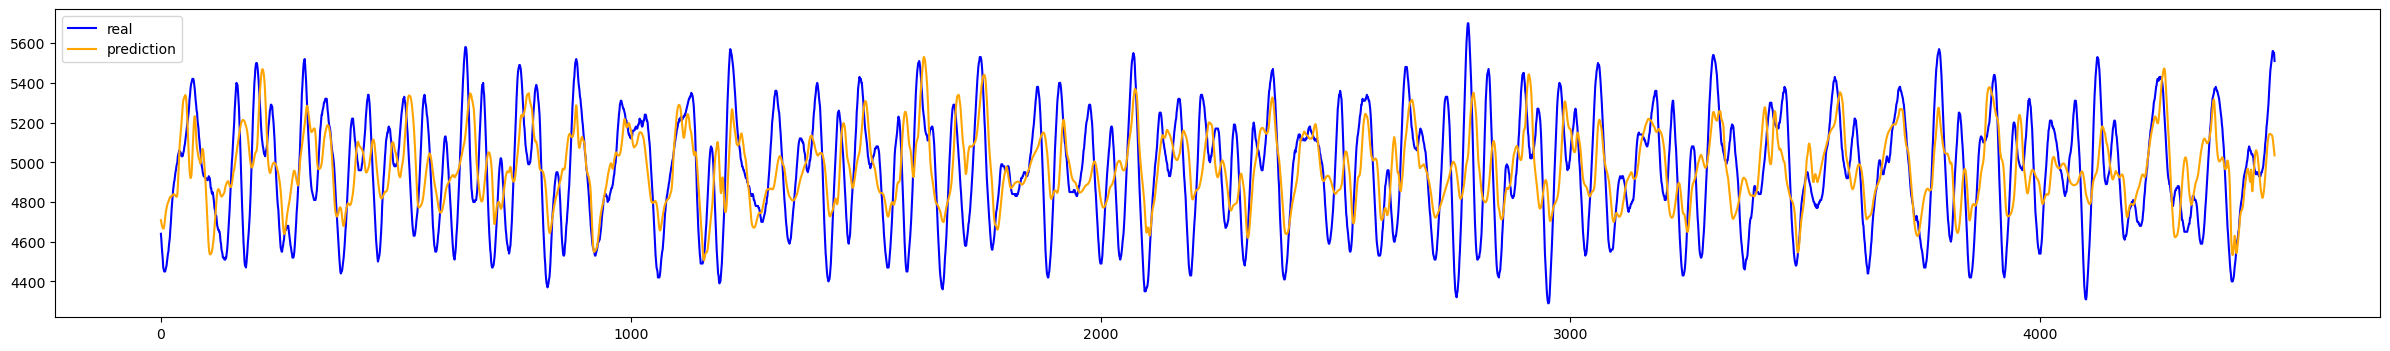

In [22]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force2500_步长30_BiLSTM.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

In [25]:
RNSE(valid50_y3_Force1,N_pre50_Y3_Force1)
RNSE(valid50_y3_Force2,N_pre50_Y3_Force2)

print('————————')

Acc(valid50_y3_Force1,N_pre50_Y3_Force1)
Acc(valid50_y3_Force2,N_pre50_Y3_Force2)

RMSE(sklearn): 0.12003249368536158
RMSE(sklearn): 0.30573598128289603
————————
Acc: 0.9175731664077167
Acc: 0.606637681464651


#### 系泊缆力联合预测（时间窗500输出；步长40）

In [13]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 12000)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_BiLSTM(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 12000)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_BiLSTM(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 12000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_BiLSTM(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 24s - loss: 0.0655 - val_loss: 0.0335 - 24s/epoch - 402ms/step
Epoch 2/30
60/60 - 11s - loss: 0.0305 - val_loss: 0.0248 - 11s/epoch - 183ms/step
Epoch 3/30
60/60 - 11s - loss: 0.0284 - val_loss: 0.0243 - 11s/epoch - 183ms/step
Epoch 4/30
60/60 - 11s - loss: 0.0277 - val_loss: 0.0238 - 11s/epoch - 184ms/step
Epoch 5/30
60/60 - 11s - loss: 0.0273 - val_loss: 0.0233 - 11s/epoch - 183ms/step
Epoch 6/30
60/60 - 12s - loss: 0.0268 - val_loss: 0.0229 - 12s/epoch - 198ms/step
Epoch 7/30
60/60 - 11s - loss: 0.0261 - val_loss: 0.0226 - 11s/epoch - 187ms/step
Epoch 8/30
60/60 - 11s - loss: 0.0255 - val_loss: 0.0222 - 11s/epoch - 184ms/step
Epoch 9/30
60/60 - 11s - loss: 0.0248 - val_loss: 0.0217 - 11s/epoch - 184ms/step
Epoch 10/30
60/60 - 11s - loss: 0.0240 - val_loss: 0.0212 - 11s/epoch - 184ms/step
Epoch 11/30
60/60 - 11s - loss: 0.0234 - val_loss: 0.0207 - 11s/epoch - 184ms/step
Epoch 12/30
60/60 - 12s - loss: 0.0231 - val_loss: 0.0204 - 12s/epoch - 199ms/step
Epoch 13/30
6

Epoch 15/30
60/60 - 11s - loss: 0.0693 - val_loss: 0.0691 - 11s/epoch - 185ms/step
Epoch 16/30
60/60 - 11s - loss: 0.0706 - val_loss: 0.0662 - 11s/epoch - 186ms/step
Epoch 17/30
60/60 - 11s - loss: 0.0680 - val_loss: 0.0633 - 11s/epoch - 187ms/step
Epoch 18/30
60/60 - 12s - loss: 0.0620 - val_loss: 0.0565 - 12s/epoch - 198ms/step
Epoch 19/30
60/60 - 12s - loss: 0.0580 - val_loss: 0.0548 - 12s/epoch - 193ms/step
Epoch 20/30
60/60 - 11s - loss: 0.0578 - val_loss: 0.0583 - 11s/epoch - 187ms/step
Epoch 21/30
60/60 - 11s - loss: 0.0575 - val_loss: 0.0556 - 11s/epoch - 187ms/step
Epoch 22/30
60/60 - 11s - loss: 0.0562 - val_loss: 0.0562 - 11s/epoch - 187ms/step
Epoch 23/30
60/60 - 12s - loss: 0.0563 - val_loss: 0.0557 - 12s/epoch - 196ms/step
Epoch 24/30
60/60 - 11s - loss: 0.0553 - val_loss: 0.0554 - 11s/epoch - 190ms/step
Epoch 25/30
60/60 - 12s - loss: 0.0558 - val_loss: 0.0551 - 12s/epoch - 192ms/step
Epoch 26/30
60/60 - 11s - loss: 0.0554 - val_loss: 0.0566 - 11s/epoch - 187ms/step
Epoc

In [14]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

94/94 [==============================] - 3s 35ms/step
(3000, 1)
(3000, 1)
(3000, 1)


In [15]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 4500, 7500, 12000)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [17]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.0230 - val_loss: 0.0167 - 2s/epoch - 148ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0167 - val_loss: 0.0157 - 106ms/epoch - 9ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0164 - val_loss: 0.0164 - 174ms/epoch - 14ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0151 - 78ms/epoch - 6ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0151 - 82ms/epoch - 7ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0150 - 100ms/epoch - 8ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0150 - 79ms/epoch - 7ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0150 - 76ms/epoch - 6ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0150 - 83ms/epoch - 7ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0150 - 81ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0150 - 96ms/epoch - 8ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0146 - val_loss: 0.0150 - 82ms/epoch - 7ms/step
Epoch 13/

Epoch 100/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 83ms/epoch - 7ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 78ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 80ms/epoch - 7ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 82ms/epoch - 7ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 72ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 80ms/epoch - 7ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 82ms/epoch - 7ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 74ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 84ms/epoch - 7ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 82ms/epoch - 7ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 73ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0149 - 80ms/epoch - 7

Epoch 198/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 66ms/epoch - 5ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 69ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 65ms/epoch - 5ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 70ms/epoch - 6ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 68ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 67ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 68ms/epoch - 6ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 65ms/epoch - 5ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 68ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 69ms/epoch - 6ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 70ms/epoch - 6ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0149 - 68ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0149 - 68ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0149 - 66ms/epoch - 5ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 71ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0149 - 69ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 70ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0149 - 66ms/epoch - 5ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 67ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 76ms/epoch - 6

Epoch 394/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 74ms/epoch - 6ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 74ms/epoch - 6ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 81ms/epoch - 7ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 79ms/epoch - 7ms/step
Epoch 398/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 399/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 65ms/epoch - 5ms/step
Epoch 400/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 401/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 75ms/epoch - 6ms/step
Epoch 402/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 81ms/epoch - 7ms/step
Epoch 403/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 71ms/epoch - 6ms/step
Epoch 404/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 405/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 68ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 67ms/epoch - 6ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 70ms/epoch - 6ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 76ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 66ms/epoch - 5ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 65ms/epoch - 5ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 71ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 70ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 71ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 75ms/epoch - 6ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 67ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 65ms/epoch - 5ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 67ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0148 - 70ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 67ms/epoch - 6ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 66ms/epoch - 5ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 78ms/epoch - 6ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 77ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 80ms/epoch - 7ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 75ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 73ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 77ms/epoch - 6ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 72ms/epoch - 6

Epoch 884/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 76ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 69ms/epoch - 6ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 73ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 90ms/epoch - 7ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 84ms/epoch - 7ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 74ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 75ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 72ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 68ms/epoch - 6ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 66ms/epoch - 5

Epoch 982/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 82ms/epoch - 7ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 76ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 72ms/epoch - 6ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 81ms/epoch - 7ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 84ms/epoch - 7ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 76ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 77ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 82ms/epoch - 7ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 82ms/epoch - 7ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 71ms/epoch - 6ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 96ms/epoch - 8ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0148 - 97ms/epoch - 8

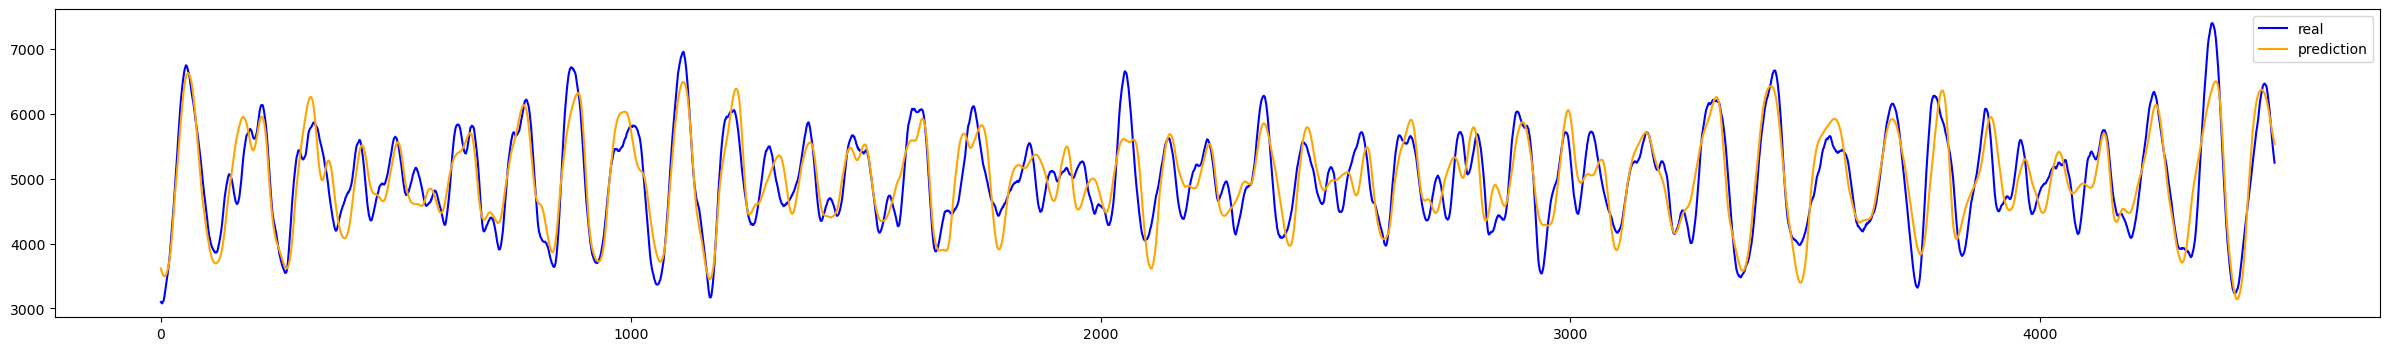

In [18]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force1500_步长40_BiLSTM.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [19]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3470:,:], 4, 539)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 4500, 7500, 12000)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [21]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/1000
12/12 - 2s - loss: 0.1020 - val_loss: 0.0991 - 2s/epoch - 147ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0856 - val_loss: 0.0906 - 111ms/epoch - 9ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0828 - val_loss: 0.0897 - 86ms/epoch - 7ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0814 - val_loss: 0.0892 - 80ms/epoch - 7ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0805 - val_loss: 0.0891 - 79ms/epoch - 7ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0803 - val_loss: 0.0895 - 88ms/epoch - 7ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0801 - val_loss: 0.0897 - 78ms/epoch - 6ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0799 - val_loss: 0.0897 - 81ms/epoch - 7ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0797 - val_loss: 0.0898 - 79ms/epoch - 7ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0796 - val_loss: 0.0898 - 80ms/epoch - 7ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0795 - val_loss: 0.0898 - 72ms/epoch - 6ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0794 - val_loss: 0.0897 - 80ms/epoch - 7ms/step
Epoch 13/100

Epoch 100/1000
12/12 - 0s - loss: 0.0782 - val_loss: 0.0896 - 73ms/epoch - 6ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0781 - val_loss: 0.0895 - 71ms/epoch - 6ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0780 - val_loss: 0.0896 - 70ms/epoch - 6ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0780 - val_loss: 0.0897 - 73ms/epoch - 6ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0779 - val_loss: 0.0898 - 75ms/epoch - 6ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0779 - val_loss: 0.0901 - 69ms/epoch - 6ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0782 - val_loss: 0.0910 - 68ms/epoch - 6ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0794 - val_loss: 0.0914 - 70ms/epoch - 6ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0812 - val_loss: 0.0890 - 66ms/epoch - 5ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0792 - val_loss: 0.0890 - 71ms/epoch - 6ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0782 - val_loss: 0.0895 - 71ms/epoch - 6ms/step
Epoch 111/1000
12/12 - 0s - loss: 0.0782 - val_loss: 0.0898 - 73ms/epoch - 6

Epoch 198/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 70ms/epoch - 6ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 71ms/epoch - 6ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 77ms/epoch - 6ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 76ms/epoch - 6ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 70ms/epoch - 6ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 70ms/epoch - 6ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 93ms/epoch - 8ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 66ms/epoch - 5ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 72ms/epoch - 6ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 71ms/epoch - 6ms/step
Epoch 208/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 71ms/epoch - 6ms/step
Epoch 209/1000
12/12 - 0s - loss: 0.0772 - val_loss: 0.0894 - 71ms/epoch - 6

Epoch 296/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 71ms/epoch - 6ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 70ms/epoch - 6ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 74ms/epoch - 6ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 70ms/epoch - 6ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 69ms/epoch - 6ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 70ms/epoch - 6ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 72ms/epoch - 6ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 72ms/epoch - 6ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 71ms/epoch - 6ms/step
Epoch 305/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 71ms/epoch - 6ms/step
Epoch 306/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 73ms/epoch - 6ms/step
Epoch 307/1000
12/12 - 0s - loss: 0.0770 - val_loss: 0.0894 - 71ms/epoch - 6

...

Epoch 590/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0907 - 70ms/epoch - 6ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0907 - 70ms/epoch - 6ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0906 - 73ms/epoch - 6ms/step
Epoch 593/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0906 - 69ms/epoch - 6ms/step
Epoch 594/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0906 - 71ms/epoch - 6ms/step
Epoch 595/1000
12/12 - 0s - loss: 0.0746 - val_loss: 0.0906 - 73ms/epoch - 6ms/step
Epoch 596/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0906 - 71ms/epoch - 6ms/step
Epoch 597/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0906 - 75ms/epoch - 6ms/step
Epoch 598/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0906 - 72ms/epoch - 6ms/step
Epoch 599/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0906 - 75ms/epoch - 6ms/step
Epoch 600/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0906 - 76ms/epoch - 6ms/step
Epoch 601/1000
12/12 - 0s - loss: 0.0745 - val_loss: 0.0906 - 74ms/epoch - 6

Epoch 688/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0900 - 68ms/epoch - 6ms/step
Epoch 689/1000
12/12 - 0s - loss: 0.0721 - val_loss: 0.0900 - 77ms/epoch - 6ms/step
Epoch 690/1000
12/12 - 0s - loss: 0.0720 - val_loss: 0.0901 - 74ms/epoch - 6ms/step
Epoch 691/1000
12/12 - 0s - loss: 0.0720 - val_loss: 0.0901 - 77ms/epoch - 6ms/step
Epoch 692/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0902 - 72ms/epoch - 6ms/step
Epoch 693/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.0902 - 72ms/epoch - 6ms/step
Epoch 694/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0903 - 77ms/epoch - 6ms/step
Epoch 695/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0904 - 73ms/epoch - 6ms/step
Epoch 696/1000
12/12 - 0s - loss: 0.0718 - val_loss: 0.0904 - 70ms/epoch - 6ms/step
Epoch 697/1000
12/12 - 0s - loss: 0.0717 - val_loss: 0.0905 - 69ms/epoch - 6ms/step
Epoch 698/1000
12/12 - 0s - loss: 0.0717 - val_loss: 0.0905 - 70ms/epoch - 6ms/step
Epoch 699/1000
12/12 - 0s - loss: 0.0716 - val_loss: 0.0906 - 70ms/epoch - 6

Epoch 786/1000
12/12 - 0s - loss: 0.0697 - val_loss: 0.0933 - 71ms/epoch - 6ms/step
Epoch 787/1000
12/12 - 0s - loss: 0.0696 - val_loss: 0.0933 - 72ms/epoch - 6ms/step
Epoch 788/1000
12/12 - 0s - loss: 0.0696 - val_loss: 0.0933 - 85ms/epoch - 7ms/step
Epoch 789/1000
12/12 - 0s - loss: 0.0696 - val_loss: 0.0933 - 86ms/epoch - 7ms/step
Epoch 790/1000
12/12 - 0s - loss: 0.0696 - val_loss: 0.0933 - 73ms/epoch - 6ms/step
Epoch 791/1000
12/12 - 0s - loss: 0.0695 - val_loss: 0.0933 - 71ms/epoch - 6ms/step
Epoch 792/1000
12/12 - 0s - loss: 0.0695 - val_loss: 0.0933 - 70ms/epoch - 6ms/step
Epoch 793/1000
12/12 - 0s - loss: 0.0695 - val_loss: 0.0933 - 71ms/epoch - 6ms/step
Epoch 794/1000
12/12 - 0s - loss: 0.0695 - val_loss: 0.0933 - 71ms/epoch - 6ms/step
Epoch 795/1000
12/12 - 0s - loss: 0.0694 - val_loss: 0.0933 - 76ms/epoch - 6ms/step
Epoch 796/1000
12/12 - 0s - loss: 0.0694 - val_loss: 0.0933 - 92ms/epoch - 8ms/step
Epoch 797/1000
12/12 - 0s - loss: 0.0694 - val_loss: 0.0933 - 76ms/epoch - 6

Epoch 884/1000
12/12 - 0s - loss: 0.0671 - val_loss: 0.0930 - 70ms/epoch - 6ms/step
Epoch 885/1000
12/12 - 0s - loss: 0.0671 - val_loss: 0.0931 - 71ms/epoch - 6ms/step
Epoch 886/1000
12/12 - 0s - loss: 0.0670 - val_loss: 0.0931 - 71ms/epoch - 6ms/step
Epoch 887/1000
12/12 - 0s - loss: 0.0669 - val_loss: 0.0930 - 71ms/epoch - 6ms/step
Epoch 888/1000
12/12 - 0s - loss: 0.0669 - val_loss: 0.0930 - 77ms/epoch - 6ms/step
Epoch 889/1000
12/12 - 0s - loss: 0.0669 - val_loss: 0.0931 - 73ms/epoch - 6ms/step
Epoch 890/1000
12/12 - 0s - loss: 0.0668 - val_loss: 0.0931 - 78ms/epoch - 6ms/step
Epoch 891/1000
12/12 - 0s - loss: 0.0668 - val_loss: 0.0931 - 73ms/epoch - 6ms/step
Epoch 892/1000
12/12 - 0s - loss: 0.0668 - val_loss: 0.0931 - 73ms/epoch - 6ms/step
Epoch 893/1000
12/12 - 0s - loss: 0.0668 - val_loss: 0.0931 - 71ms/epoch - 6ms/step
Epoch 894/1000
12/12 - 0s - loss: 0.0667 - val_loss: 0.0931 - 66ms/epoch - 5ms/step
Epoch 895/1000
12/12 - 0s - loss: 0.0667 - val_loss: 0.0931 - 72ms/epoch - 6

Epoch 982/1000
12/12 - 0s - loss: 0.0652 - val_loss: 0.0949 - 73ms/epoch - 6ms/step
Epoch 983/1000
12/12 - 0s - loss: 0.0657 - val_loss: 0.0951 - 70ms/epoch - 6ms/step
Epoch 984/1000
12/12 - 0s - loss: 0.0667 - val_loss: 0.0961 - 71ms/epoch - 6ms/step
Epoch 985/1000
12/12 - 0s - loss: 0.0684 - val_loss: 0.0994 - 70ms/epoch - 6ms/step
Epoch 986/1000
12/12 - 0s - loss: 0.0719 - val_loss: 0.1025 - 71ms/epoch - 6ms/step
Epoch 987/1000
12/12 - 0s - loss: 0.0758 - val_loss: 0.0988 - 70ms/epoch - 6ms/step
Epoch 988/1000
12/12 - 0s - loss: 0.0757 - val_loss: 0.0993 - 73ms/epoch - 6ms/step
Epoch 989/1000
12/12 - 0s - loss: 0.0703 - val_loss: 0.0959 - 70ms/epoch - 6ms/step
Epoch 990/1000
12/12 - 0s - loss: 0.0660 - val_loss: 0.0943 - 73ms/epoch - 6ms/step
Epoch 991/1000
12/12 - 0s - loss: 0.0650 - val_loss: 0.0945 - 71ms/epoch - 6ms/step
Epoch 992/1000
12/12 - 0s - loss: 0.0648 - val_loss: 0.0949 - 70ms/epoch - 6ms/step
Epoch 993/1000
12/12 - 0s - loss: 0.0645 - val_loss: 0.0941 - 71ms/epoch - 6

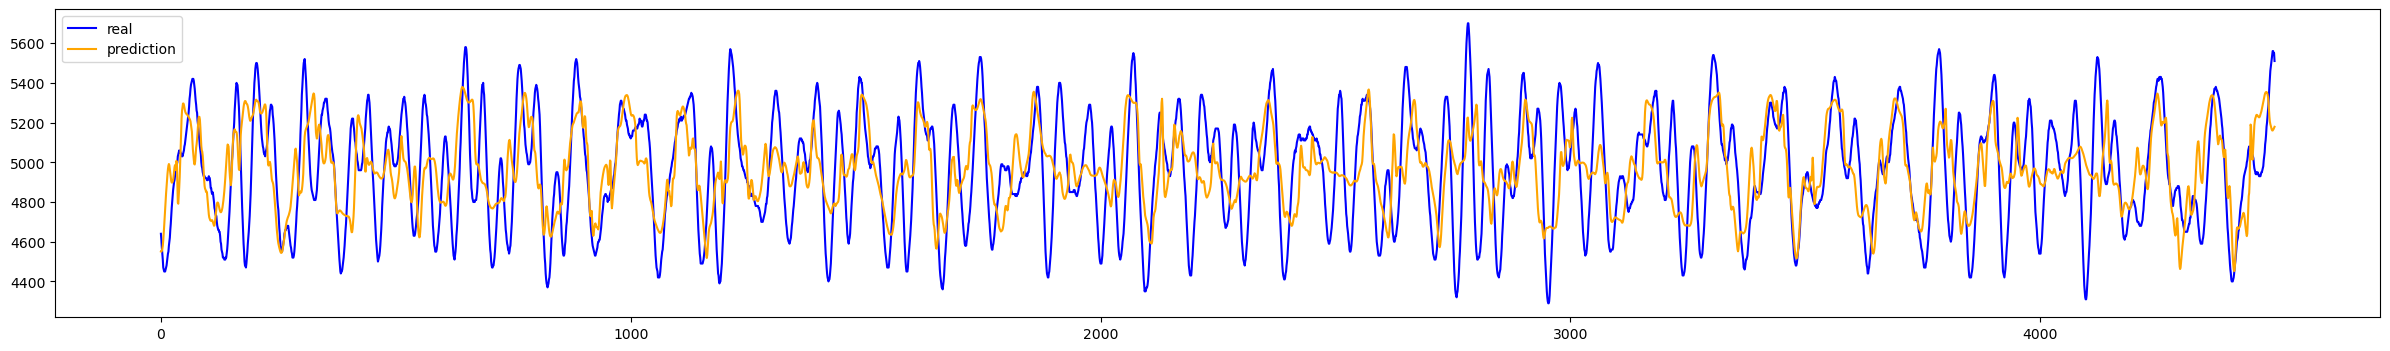

In [22]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force2500_步长40_BiLSTM.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')

In [23]:
RNSE(valid50_y4_Force1,N_pre50_Y4_Force1)
RNSE(valid50_y4_Force2,N_pre50_Y4_Force2)

print('————————')

Acc(valid50_y4_Force1,N_pre50_Y4_Force1)
Acc(valid50_y4_Force2,N_pre50_Y4_Force2)

RMSE(sklearn): 0.12182093749965123
RMSE(sklearn): 0.30782205169331434
————————
Acc: 0.9180721700092868
Acc: 0.6335930361192884
